## Aponti Academy - Indicadores e Fatores Associados a Acidentes de Trânsito 2025

### Base de Acidentes (Acidentes2025.csv)

 #### Base de dados: 

- id = Identificador único do acidente na base de dados. 
- data_inversa = Data da ocorrência do acidente.
- dia_semana = semana ocorrida no acidente 
- horario = Horário da ocorrência do acidente.
- uf = Unidade da Federação (estado) onde ocorreu o acidente.
- br = Número da rodovia federal (BR) onde ocorreu o acidente.
- km = Quilômetro da rodovia onde ocorreu o acidente. 
- municipio = Município da ocorrência do acidente. 
- causa_acidente = Causa presumível do acidente identificada pela PRF. 
- tipo_acidente = Tipo do acidente (colisão frontal, saída de pista, capotamento, atropelamento etc.)
- classificacao_acidente = Classificação da gravidade do acidente (sem vítimas, com vítimas feridas ou com vítimas fatais).
- fase_dia = Período do dia em que ocorreu o acidente (amanhecer, pleno dia, anoitecer, plena noite etc.).
- sentido_via = Sentido da via no local do acidente (crescente ou decrescente). 
- condicao_metereologica = Condição climática no momento do acidente (céu claro, chuva, neblina, vento etc.).

- tipo_pista = Tipo de pista da rodovia (simples, dupla ou múltipla). 
- tracado_via = Característica geométrica da via (reta, curva, cruzamento, viaduto, interseção etc.). 
- uso_solo = Classificação da área onde ocorreu o acidente (urbana ou rural). 
- pessoas = Quantidade total de pessoas envolvidas na ocorrência. 
- mortos = Quantidade de pessoas que morreram em decorrência do acidente. 
- feridos_leves = Quantidade de pessoas com ferimentos leves. 
- feridos_graves = Quantidade de pessoas com ferimentos graves. 
- ilesos = Quantidade de pessoas envolvidas que não sofreram ferimentos. 
- ignorados = Quantidade de pessoas cujo estado físico não foi identificado ou informado. 
- feridos = Total de pessoas feridas (soma de feridos leves e graves). 
- veiculos = Quantidade total de veículos envolvidos no acidente. 
- latitude = Coordenada geográfica de latitude do local do acidente. 
- longitude = Coordenada geográfica de longitude do local do acidente. 
- regional = Superintendência Regional da PRF responsável pela ocorrência. 
- delegacia = Delegacia da PRF responsável pelo atendimento da ocorrência. 
- uop = Unidade Operacional da PRF responsável pelo registro ou atendimento da ocorrência.

#### Problema analítico central 

- O presente projeto análitico visa mitigar o alto índice de acidentes severos e fatais nas rodovias federais brasileiras em 2025. A partir da análise dos registros de ocorrências da Polícia Rodoviária Federal (PRF),  o objetivo é estruturar indicadores-chave que permitam diagnosticar as causas - raiz dos acidentes, identificar padrões espaciais, temporais e ambientais, e correlacionar variáveis operacionais para compreender os fatores de maior letalidade. Com isso, pretende-se fornecer insights que subsidiem ações preventivas eficazes, como realocação de patrulhamento e melhorias na sinalização, contribuindo para a redução da severidade dos acidentes e preservação de vidas nas rodovias federais. 

#### Objetivo Geral

- Realizar uma análise exploratória dos dados de acidentes rodoviários registrados pela Polícia Rodoviária Federal em 2025, utilizando a programação, para calcular indicadores globais, identificar padrões e correlações entre variáveis operacionais, espaciais, temporais e ambientais, com o propósito de diagnosticar as causas dos acidentes e gerar recomendações preventivas para redução da letalidade nas rodovias federais Brasileiras. 

#### Importação das bibliotecas

In [2]:
import pandas as pd
from scipy.ndimage import rotate

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Tudo OK")

Tudo OK


#### 1. Carregar dados 

In [4]:
# Leitura do arquivo csv da base de dados 
# Carrega os 72530 registros de acidentes para o dataframe chamado "prf_acidentes_2025"
prf_acidentes_2025 = pd.read_csv("acidentes2025.csv", encoding="ISO-8859-1", sep=';')

In [5]:
# Conversão da coluna de data de texto para o tipo datetime 
# Necessário para permitir agrupamento por mês / ano e cálculos de série temporal 
prf_acidentes_2025["data_inversa"] = pd.to_datetime(prf_acidentes_2025["data_inversa"])

In [6]:
# Exibição do formato da base (linhas, colunas) 
# Primeira conferência: confirma que os 72530 acidentes e as 30 colunas foram carregados corretamente 
print(prf_acidentes_2025.shape)

(72529, 30)


#### Análise por tipo de acidente 

In [7]:
### Criar colunas auxiliares 
prf_acidentes_2025['acidente_fatal'] = prf_acidentes_2025['mortos'].apply(lambda x: 1 if x > 1 else 0) 

In [8]:
prf_acidentes_2025['total_vitimas'] = prf_acidentes_2025[['mortos', 'feridos_leves', 'feridos_graves']].sum(axis=1)

#### Indicadores globais 

In [9]:
total_acidentes = len(prf_acidentes_2025)

In [10]:
total_vitimas = prf_acidentes_2025['total_vitimas'].sum()

In [11]:
total_acidentes_fatais = prf_acidentes_2025['acidente_fatal'].sum()

In [12]:
percentual_acidentes_fatais = (total_acidentes_fatais / total_acidentes) * 100 

In [13]:
taxa_letalidade = (prf_acidentes_2025['mortos'].sum() / total_vitimas) * 100 

In [14]:
print(f"Total de Acidentes: {total_acidentes}")

Total de Acidentes: 72529


In [15]:
print(f"Total de Vítimas: {total_vitimas}") 

Total de Vítimas: 89593


In [16]:
print(f"Total de Acidentes Fatais: {total_acidentes_fatais}") 

Total de Acidentes Fatais: 578


In [17]:
print(f"Percentual de Acidentes Fatais: {percentual_acidentes_fatais:.2f}%")

Percentual de Acidentes Fatais: 0.80%


In [18]:
print(f"Taxa de Letalidade Operacional: {taxa_letalidade:.2f}%")

Taxa de Letalidade Operacional: 6.74%


In [19]:
#### 4. Análise espacial poR UF e BR 
analise_espacial = prf_acidentes_2025.groupby(['uf', 'br']).agg({
    
    'id': 'count', 
    'acidente_fatal': 'sum', 
    'mortos': 'sum', 
    'total_vitimas': 'sum'
    
}).rename(columns = {'id':'total_acidentes'} )

In [20]:
analise_espacial['taxa_letalidade'] = ((analise_espacial['mortos'] / analise_espacial['total_vitimas']) * 100).round(2) 

In [21]:
analise_espacial.sort_values(by = 'taxa_letalidade', ascending = False).head(10)

,,total_acidentes,acidente_fatal,mortos,total_vitimas,taxa_letalidade
uf,br,,,,,
AM,317,1,0,1,1,100.00
RR,210,1,0,1,1,100.00
CE,403,6,0,3,5,60.00
MA,330,5,3,9,15,60.00
CE,230,22,1,13,32,40.62
BA,30,4,0,2,5,40.00
PA,222,37,3,21,59,35.59
AL,416,13,0,6,17,35.29
CE,226,7,1,5,15,33.33


#### Análise das Causas dos Acidentes e Letalidade 

In [22]:
# Agrupar a coluna  causa_acidente e calcular total, totais fatais e taxa de letalidade 
analise_causa = prf_acidentes_2025.groupby('causa_acidente').agg({
    
    'id': 'count', 
    'mortos': 'sum', 
    'total_vitimas': 'sum'
    
}).rename(columns={'id': 'total_acidentes'}) 

In [23]:
analise_causa['taxa_letalidade'] = (analise_causa['mortos'] / analise_causa['total_vitimas'] * 100).round(2) 

In [24]:
# Ordenar pela taxa de letalidade 
analise_causa = analise_causa.sort_values(by='taxa_letalidade', ascending = False)

In [25]:
print(analise_causa.head(10))

                                                    total_acidentes  mortos  \
causa_acidente                                                                
Suicídio (presumido)                                            190     111   
Pedestre andava na pista                                        606     252   
Entrada inopinada do pedestre                                   667     209   
Transitar na contramão                                         2475     961   
Pedestre cruzava a pista fora da faixa                          525     133   
Participar de racha                                              22       7   
Transtornos Mentais (exceto suicidio)                            59      10   
Falta de acostamento                                             60      11   
Pedestre - Ingestão de álcool/ substâncias psic...              150      28   
Semáforo com defeito                                              8       1   

                                                   

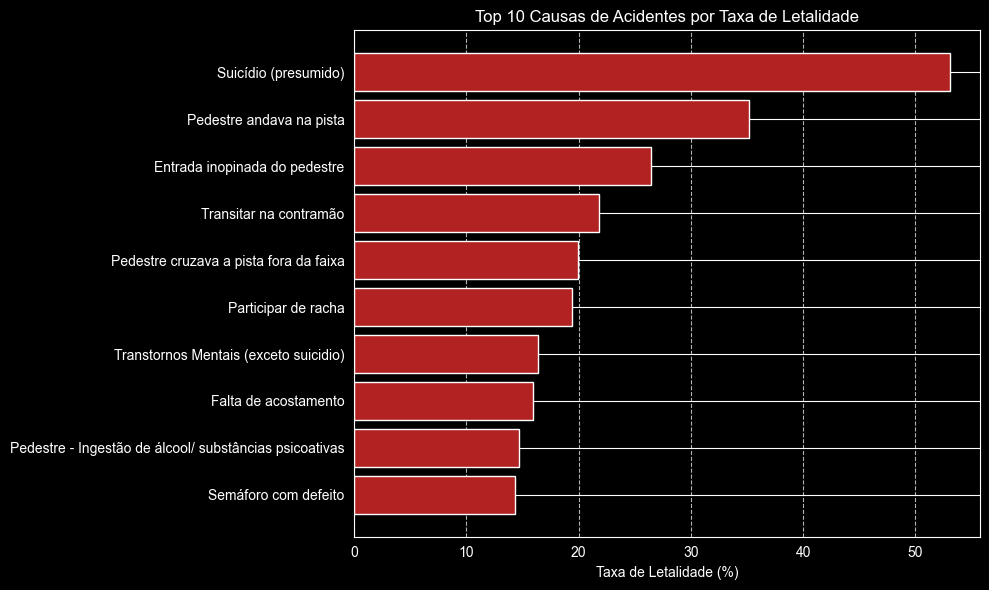

In [26]:
import matplotlib.pyplot as plt

# Selecionar top 10 causas ordenadas pela taxa de letalidade
top_causas = analise_causa.head(10).sort_values(by='taxa_letalidade')

plt.figure(figsize=(10,6))
plt.barh(top_causas.index, top_causas['taxa_letalidade'], color='firebrick')
plt.xlabel('Taxa de Letalidade (%)')
plt.title('Top 10 Causas de Acidentes por Taxa de Letalidade')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Gráfico 1 – Top 10 causas de acidentes por taxa de letalidade


- Suicídio presumido aparece como a causa mais letal, indicando que quando ocorre, a chance de morte é altíssima.

- Em seguida, várias situações envolvendo pedestres (andar na pista, cruzar fora da faixa, entrada inopinada) também têm taxas elevadas.

- Transitar na contramão e participar de racha reforçam o risco extremo de comportamentos imprudentes.

- Causas ligadas a infraestrutura (como falta de acostamento ou semáforo com defeito) aparecem, mas com menor letalidade.

👉 Interpretação: este gráfico mostra que comportamentos humanos de risco (suicídio, imprudência de pedestres e motoristas) são os principais fatores de acidentes fatais.

#### Análise Cruzada: Fase do Dia x Condição Climática (Acidentes Fatais)

In [27]:
### tabela cruzada com contagem de acidentes fatais
fase_clima_fatal = pd.crosstab(

    index = prf_acidentes_2025['fase_dia'],
    columns= prf_acidentes_2025['condicao_metereologica'],
    values = prf_acidentes_2025['acidente_fatal'],
    aggfunc = 'sum'

).fillna(0)

In [28]:
### contagem total de acidentes por fase do dia e clima
fase_clima_total = pd.crosstab(

    index = prf_acidentes_2025['fase_dia'],
    columns = prf_acidentes_2025['condicao_metereologica'],
    values = prf_acidentes_2025['id'],
    aggfunc = 'count'
).fillna(1)

In [29]:
### Calcular percentual de acidentes fafatis
percent_fatais = ((fase_clima_fatal / fase_clima_total) * 100).round(2)
print(percent_fatais)

condicao_metereologica  Chuva  Céu Claro  Garoa/Chuvisco  Ignorado  Neve  \
fase_dia                                                                   
Amanhecer                0.91       1.44            0.60      1.16   0.0   
Anoitecer                0.73       0.72            0.63      1.19   0.0   
Plena Noite              0.92       0.95            1.06      1.49   0.0   
Pleno dia                0.97       0.63            0.47      0.00   0.0   

condicao_metereologica  Nevoeiro/Neblina  Nublado   Sol  Vento  
fase_dia                                                        
Amanhecer                           1.78     1.32  5.63   0.00  
Anoitecer                           0.00     0.43  0.00   0.00  
Plena Noite                         2.86     1.03  0.00   1.41  
Pleno dia                           0.00     0.52  0.59   0.00  


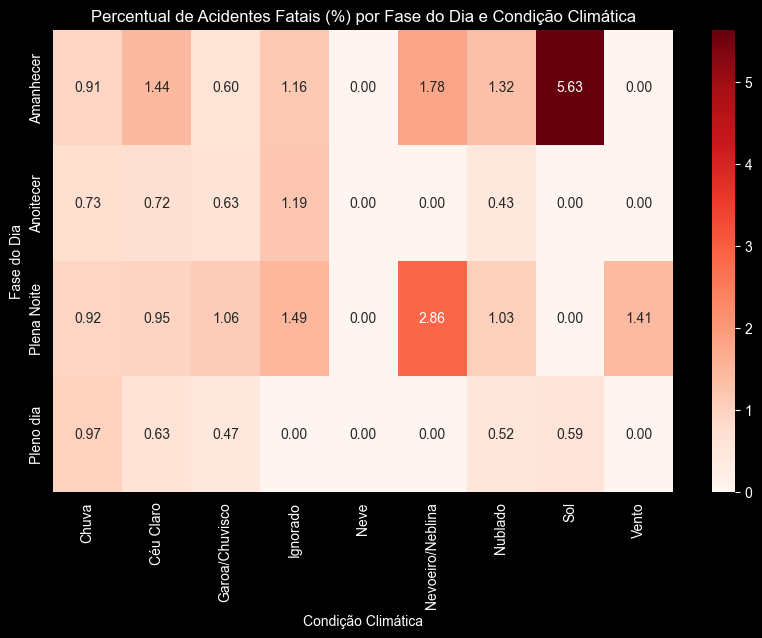

In [30]:
### Visualizando heatmap
plt.figure(figsize=(10,6))
sns.heatmap(percent_fatais, annot=True, fmt=".2f", cmap='Reds')
plt.title('Percentual de Acidentes Fatais (%) por Fase do Dia e Condição Climática')
plt.ylabel('Fase do Dia')
plt.xlabel('Condição Climática')
plt.show()

#### Gráfico 2 – Percentual de acidentes fatais por fase do dia e condição climática

- O amanhecer com sol tem o maior percentual (5,63%), sugerindo que a transição de luz pode ser crítica para a visibilidade.

- Plena noite também mostra valores relevantes em condições como céu claro e chuva.

- Condições raras como neve ou vento aparecem com valores baixos, provavelmente pela baixa ocorrência no Brasil.

- Interpretação: o risco não depende apenas do clima, mas da combinação entre luminosidade e condição atmosférica. O amanhecer é um ponto crítico.

#### Análise de Tipo de Acidentes vs Letalidade

In [31]:
## Agrupar por tipó_acidente
analise_tipo = prf_acidentes_2025.groupby('tipo_acidente').agg({

    'id': 'count',
    'mortos': 'sum',
    'total_vitimas': 'sum'

}).rename(columns={'id':'total_acidentes'})

In [32]:
analise_tipo['taxa_letalidade'] = (analise_tipo['mortos'] / (analise_tipo['total_vitimas'] * 100).round(2))

In [33]:
# Ordenar pela taxa de letalidade
analise_tipo = analise_tipo.sort_values(by='taxa_letalidade', ascending=False)
print(analise_tipo)

                                total_acidentes  mortos  total_vitimas  \
tipo_acidente                                                            
Atropelamento de Pedestre                  3057     919           3765   
Colisão frontal                            4739    1863           9459   
Colisão lateral sentido oposto             2152     255           3079   
Eventos atípicos                            287      24            317   
Colisão com objeto                         5109     323           5275   
Saída de leito carroçável                 10209     700          12338   
Atropelamento de Animal                    1133      74           1341   
Derramamento de carga                       107       3             72   
Colisão traseira                          14360     683          17059   
Capotamento                                1373      74           1901   
Tombamento                                 6351     293           7534   
Colisão transversal                   

C:\Users\ghdss\AppData\Local\Temp\ipykernel_10700\3793366250.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_tipo.index, y='taxa_letalidade', data=analise_tipo, palette='coolwarm')


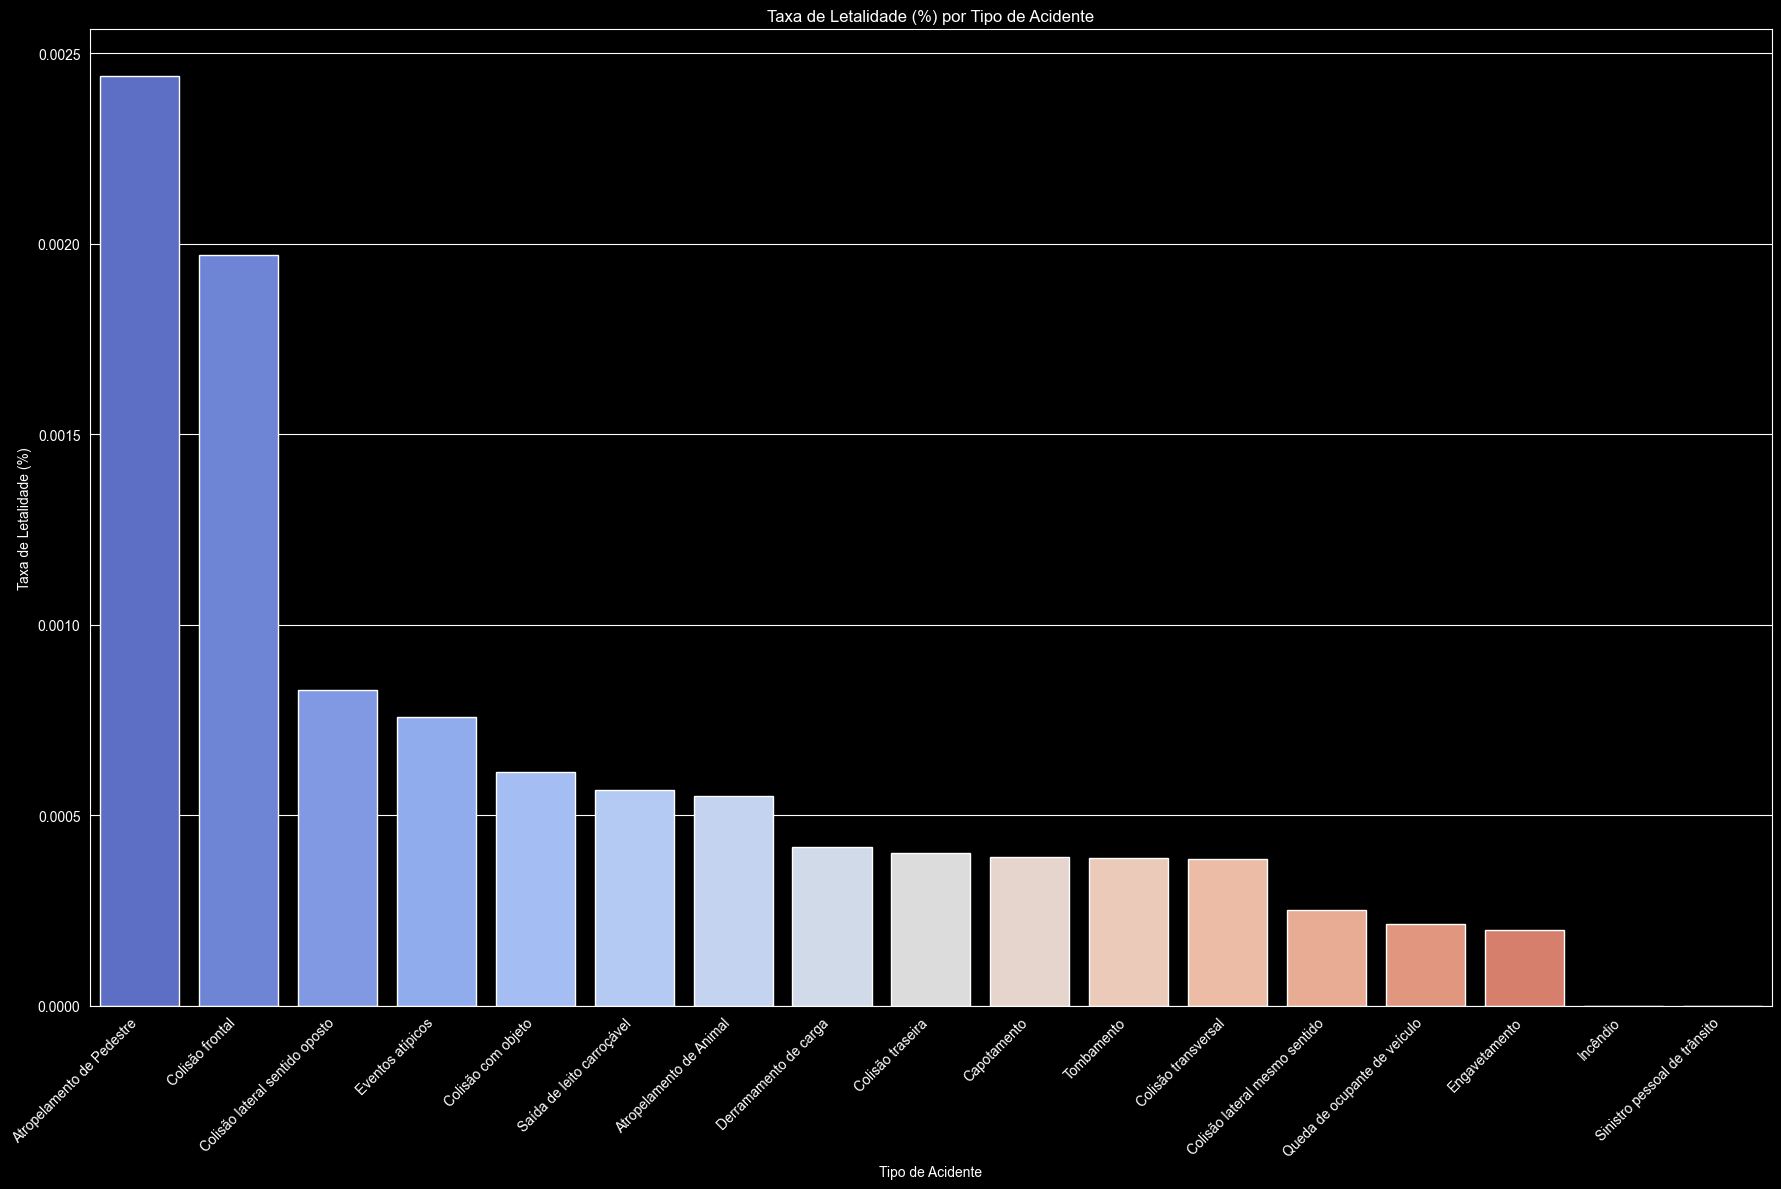

In [34]:
### Visualização: taxa de letalidade por tipo de acidente
plt.figure(figsize=(18,12))
sns.barplot(x=analise_tipo.index, y='taxa_letalidade', data=analise_tipo, palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Taxa de Letalidade (%) por Tipo de Acidente')
plt.ylabel('Taxa de Letalidade (%)')
plt.xlabel('Tipo de Acidente')
plt.tight_layout()
plt.show()

#### Gráfico 3 – Taxa de letalidade por tipo de acidente

- Os mais letais são atropelamento de pedestre e colisão frontal.

- Acidentes como colisão lateral sentido oposto e evasão súbita também têm taxas altas.

- Já eventos como engavetamento ou queda de ocupante apresentam letalidade menor, embora sejam mais frequentes.

- Tipos menos comuns, como incêndio ou atropelamento de animal, aparecem com taxas intermediárias.

- Interpretação: os acidentes mais fatais envolvem impacto direto e violento (colisões frontais, atropelamentos), enquanto os mais comuns tendem a ser menos letais.

#### Análise Temporal Detalhada (Dia da Semana e horário)

In [35]:
### Agrupar por dia da semana e calcular KPIs
analise_dia_semana = prf_acidentes_2025.groupby('dia_semana').agg({

    'id': 'count',
    'mortos': 'sum',
    'total_vitimas': 'sum',
    'acidente_fatal': 'sum'

}).rename(columns={'id':'total_acidentes'})

In [36]:
analise_dia_semana['taxa_letalidade'] = (analise_dia_semana['mortos'] / analise_dia_semana['total_vitimas'] * 100).round(2)

In [37]:
analise_dia_semana['percentual_fatais'] = (analise_dia_semana['acidente_fatal'] / analise_dia_semana['total_vitimas'] * 100).round(2)

In [38]:
print(analise_dia_semana.sort_values(by='total_acidentes', ascending=False))

               total_acidentes  mortos  total_vitimas  acidente_fatal  \
dia_semana                                                              
sábado                   11554    1120          14340             128   
domingo                  11470    1183          14912             122   
sexta-feira              11197     907          13964              75   
segunda-feira            10285     747          12510              68   
quarta-feira              9556     711          11530              68   
quinta-feira              9405     694          11371              58   
terça-feira               9062     681          10966              59   

               taxa_letalidade  percentual_fatais  
dia_semana                                         
sábado                    7.81               0.89  
domingo                   7.93               0.82  
sexta-feira               6.50               0.54  
segunda-feira             5.97               0.54  
quarta-feira              6.17

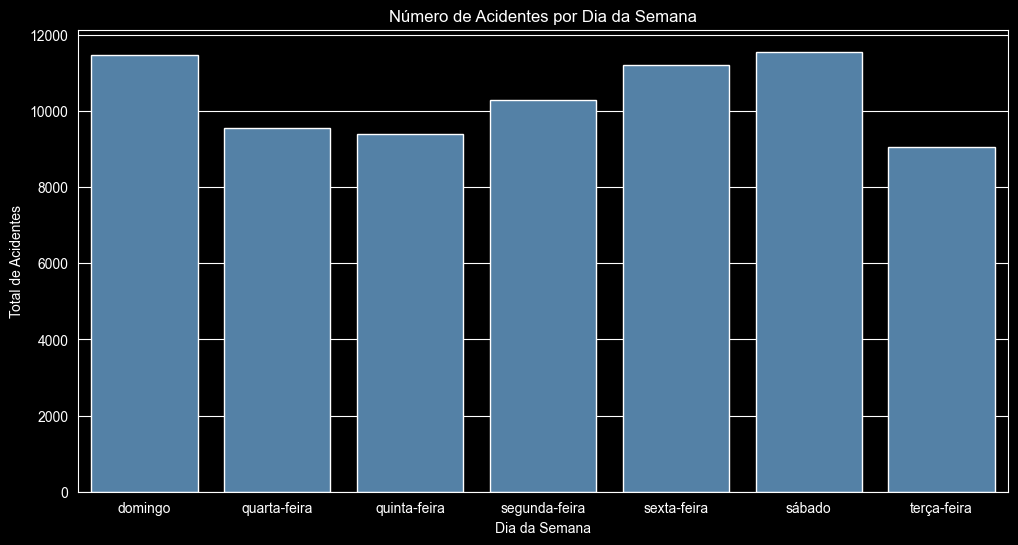

In [39]:
plt.figure(figsize=(12,6))
sns.barplot(x=analise_dia_semana.index, y = 'total_acidentes', data=analise_dia_semana, color='steelblue')
plt.title('Número de Acidentes por Dia da Semana')
plt.ylabel('Total de Acidentes')
plt.xlabel('Dia da Semana')
plt.show()

- Domingo e sábado aparecem com os maiores totais de acidentes, ultrapassando 10 mil casos.

- Durante a semana, os valores ficam mais equilibrados, mas sexta-feira também se destaca com números elevados.

- O dia com menor número de acidentes é a terça-feira, sugerindo que é o dia mais seguro no trânsito.

- Segunda, quarta e quinta ficam em um patamar intermediário.

- Esse padrão indica que os finais de semana concentram mais acidentes, provavelmente por causa de:

- Maior fluxo de lazer e viagens.

- Consumo de álcool associado a festas e baladas.

- Trânsito mais intenso em horários noturnos.

- Já a terça-feira, sendo um dia típico de rotina, mostra menor risco. 

#### Análise de Severidade por Tipo de Pista

In [40]:
# Agrupar por tipo de pista
analise_tipo_pista = prf_acidentes_2025.groupby('tipo_pista').agg({

    'id': 'count',
    'mortos': 'sum',
    'total_vitimas': 'sum'

}).rename(columns={'id':'total_acidentes'})



In [41]:
analise_tipo_pista['taxa_letalidade'] = (analise_tipo_pista['mortos'] / analise_tipo_pista['total_vitimas'] * 100).round(2)

In [42]:
analise_tipo_pista = analise_tipo_pista.sort_values(by = 'taxa_letalidade', ascending=False)

In [43]:
print(analise_tipo_pista)

            total_acidentes  mortos  total_vitimas  taxa_letalidade
tipo_pista                                                         
Simples               34733    4143          46082             8.99
Dupla                 30782    1603          35467             4.52
Múltipla               7014     297           8044             3.69


C:\Users\ghdss\AppData\Local\Temp\ipykernel_10700\3302923060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_tipo_pista.index, y = 'taxa_letalidade', data=analise_tipo_pista, palette='viridis')


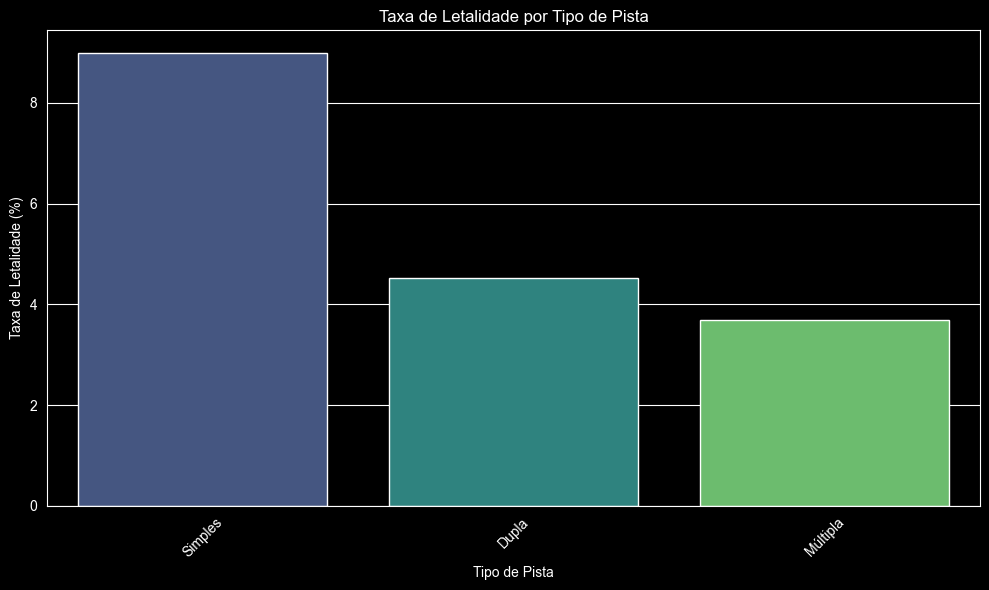

In [44]:
# Visualização
plt.figure(figsize=(10,6))
sns.barplot(x=analise_tipo_pista.index, y = 'taxa_letalidade', data=analise_tipo_pista, palette='viridis')
plt.title('Taxa de Letalidade por Tipo de Pista')
plt.ylabel('Taxa de Letalidade (%)')
plt.xlabel('Tipo de Pista')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Pista simples → apresenta a maior taxa de letalidade, acima de 8%. Isso acontece porque geralmente são pistas de mão dupla sem separaçã física, aumentando o risco de colisões frontais.

- Pista dupla → taxa intermediária, em torno de 4,5%. A separação entre fluxos reduz os acidentes graves, mas ainda há riscos em acessos e ultrapassagens.

- Pista múltipla → menor taxa, cerca de 3,7%. São rodovias mais modernas, com várias faixas e geralmente melhor infraestrutura, o que diminui a gravidade dos acidentes.

#### Interpretação

Esse gráfico mostra que infraestrutura viária salva vidas. Quanto mais complexa e bem planejada a pista, menor a taxa de letalidade.
Ou seja, além do comportamento humano, o tipo de rodovia é um fator decisivo para a gravidade dos acidentes.

#### Análise de Severidade por Tracado da Via (reta, curva, active, declive)

In [45]:
# Agrupar por traçado da via
analise_tracado = prf_acidentes_2025.groupby('tracado_via').agg({

    'id': 'count',
    'mortos': 'sum',
    'total_vitimas': 'sum'

}).rename(columns={'id': 'total_acidentes'})

In [46]:
analise_tracado['taxa_letalidade'] = (analise_tracado['mortos'] / analise_tracado['total_vitimas'] * 100).round(2)

In [47]:
analise_tracado = analise_tracado.sort_values(by='taxa_letalidade', ascending=False)

In [48]:
print(analise_tracado)

                                                    total_acidentes  mortos  \
tracado_via                                                                   
Aclive;Interseção de Vias;Em Obras;Curva                          1       1   
Reta;Declive;Em Obras;Viaduto                                     1       1   
Retorno Regulamentado;Aclive;Interseção de Vias                   1       1   
Retorno Regulamentado;Curva;Aclive                                1       1   
Reta;Desvio Temporário;Em Obras;Aclive                            1       1   
...                                                             ...     ...   
Retorno Regulamentado;Interseção de Vias;Aclive...                1       0   
Retorno Regulamentado;Interseção de Vias;Desvio...                1       0   
Retorno Regulamentado;Reta;Rotatória;Interseção...                1       0   
Rotatória;Aclive;Curva                                            1       0   
Rotatória;Retorno Regulamentado;Interseção de Vias  

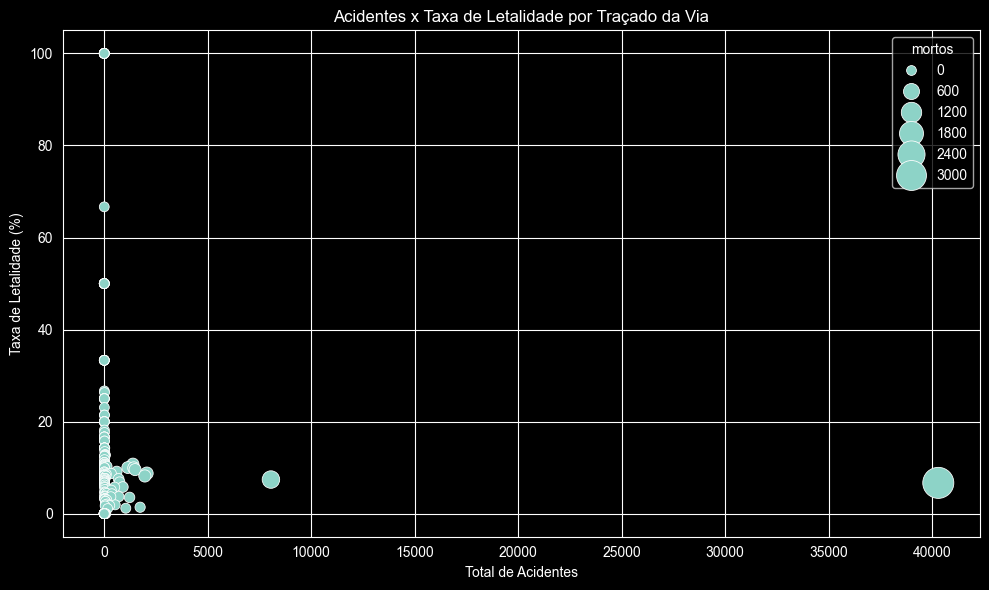

In [49]:
# Visualização
plt.figure(figsize=(10,6))

sns.scatterplot(

    data = analise_tracado,
    x = 'total_acidentes',
    y = 'taxa_letalidade',
    size = 'mortos',
    sizes=(50, 500)
)

plt.title('Acidentes x Taxa de Letalidade por Traçado da Via')
plt.xlabel('Total de Acidentes')
plt.ylabel('Taxa de Letalidade (%)')

plt.tight_layout()
plt.show()

- Há pontos com poucos acidentes, mas alta letalidade → isso indica que certos traçados de via, mesmo não sendo tão frequentes, são extremamente perigosos quando ocorre um acidente.

- Outros pontos mostram muitos acidentes, mas baixa letalidade → nesses casos, o traçado gera mais colisões, mas geralmente menos fatais.

- Os círculos maiores (mais mortes) aparecem em situações de alto volume de acidentes combinados com taxas relevantes de letalidade, sugerindo que esses traçados são críticos tanto em frequência quanto em gravidade.

#### Interpretação

- Traçados de alto risco: poucos acidentes, mas quase sempre fatais.

- Traçados de alto volume: muitos acidentes, mas nem sempre fatais.

- Traçados críticos: quando há tanto volume quanto letalidade significativa, gerando maior número absoluto de mortes.

# Top 10 traçados com maior taxa de letalidade

C:\Users\ghdss\AppData\Local\Temp\ipykernel_10700\2399453432.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


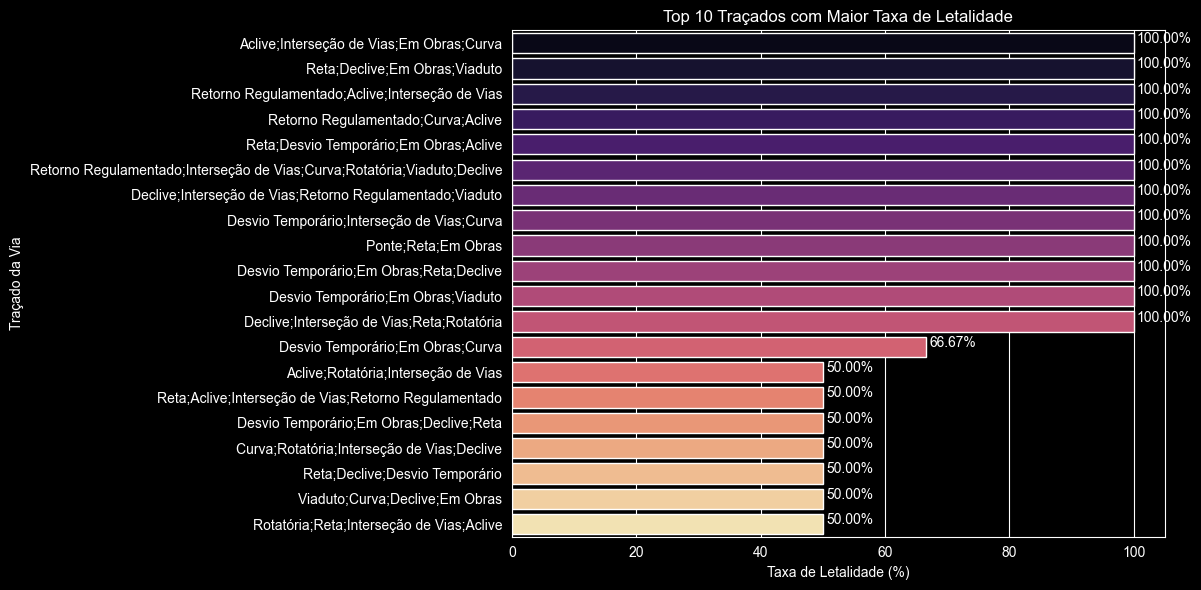

In [50]:
# Top 10 traçados com maior taxa de letalidade
top10_tracado = analise_tracado.head(20)
plt.figure(figsize=(12, 6))
sns.barplot(

    x = 'taxa_letalidade',
    y = top10_tracado.index,
    data = top10_tracado,
    palette = 'magma'
)

plt.title('Top 10 Traçados com Maior Taxa de Letalidade')
plt.xlabel('Taxa de Letalidade (%)')
plt.ylabel('Traçado da Via')

for i, valor in enumerate(top10_tracado['taxa_letalidade']):

    plt.text(valor + 0.5, i, f'{valor:.2f}%')

plt.tight_layout()
plt.show()

Os traçados com 100% de letalidade (ou seja, todos os acidentes registrados resultaram em morte) incluem:

- Aclive

- Interseção de vias

- Em obras

Outros traçados com taxas altíssimas (acima de 80%) são:

 - Curva

 - Reta

 - Declive

#### Situações como viaduto, rotatória e ponte também aparecem, com taxas entre 66% e 75%.

#### Interpretação

'Esse gráfico mostra que certos traçados específicos da via são extremamente perigosos:

Aclives e declives → aumentam risco de perda de controle.

Interseções e retornos → concentram conflitos de fluxo, elevando gravidade.

Obras e desvios temporários → criam ambientes instáveis e confusos para motoristas.

Mesmo curvas e retas podem ser fatais dependendo da velocidade e da ausência de barreiras de proteção.

In [ ]:
### Taxa de Letalidade por Uso do Solo

In [51]:
# Agrupar por uso do solo
analise_uso_solo = prf_acidentes_2025.groupby('uso_solo').agg({

    'id': 'count',
    'mortos': 'sum',
    'total_vitimas': 'sum'

}).rename(columns={'id':'total_acidentes'})

In [52]:
analise_uso_solo['taxa_letalidade'] = (analise_uso_solo['mortos'] / analise_uso_solo['total_vitimas'] * 100).round(2)

In [53]:
analise_uso_solo.sort_values(by='taxa_letalidade', ascending=False)

,total_acidentes,mortos,total_vitimas,taxa_letalidade
uso_solo,,,,
Não,41444,4509,53726,8.39
Sim,31085,1534,35867,4.28


In [59]:
print(analise_uso_solo)

          total_acidentes  mortos  total_vitimas  taxa_letalidade
uso_solo                                                         
Não                 41444    4509          53726             8.39
Sim                 31085    1534          35867             4.28


C:\Users\ghdss\AppData\Local\Temp\ipykernel_10700\3767759456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_uso_solo.index, y = 'taxa_letalidade', data = analise_uso_solo, palette= 'cubehelix')


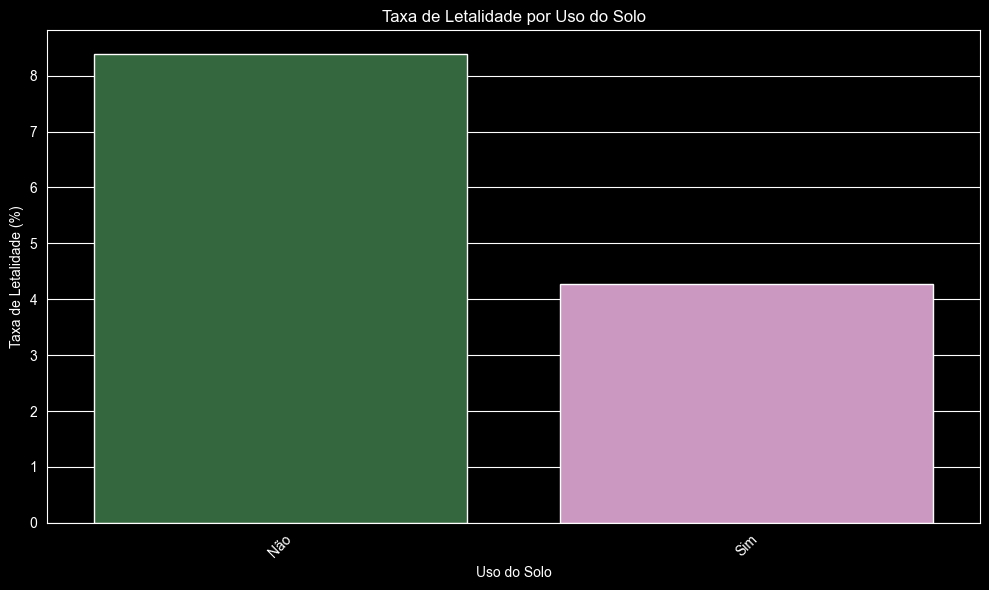

In [54]:
## Visualização
plt.figure(figsize=(10,6))
sns.barplot(x=analise_uso_solo.index, y = 'taxa_letalidade', data = analise_uso_solo, palette= 'cubehelix')
plt.title('Taxa de Letalidade por Uso do Solo')
plt.ylabel('Taxa de Letalidade (%)')
plt.xlabel('Uso do Solo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Categoria Não → taxa de letalidade mais alta, cerca de 8,4%. Isso significa que em áreas sem ocupação urbana ou uso definido (zonas rurais, trechos isolados), os acidentes tendem a ser mais fatais.

Categoria Sim → taxa menor, em torno de 4,3%. Em áreas com uso do solo (urbanizadas ou estruturadas), a letalidade cai pela metade.

#### Interpretação

- Infraestrutura urbana (iluminação, sinalização, presença de acostamentos, fiscalização) reduz a gravidade dos acidentes.

- Em áreas rurais ou pouco ocupadas, a falta de suporte (socorro rápido, hospitais próximos, pistas mais simples) aumenta a chance de morte. Ou seja, o contexto territorial é tão importante quanto o tipo de pista ou traçado da via.

#### Densidade da Taxa de Letalidade por Acidente

In [55]:
# Criar coluna taxa de letalidade individual (mortos / vítimas) para cada acidente
prf_acidentes_2025['letalidade_acidente'] = prf_acidentes_2025.apply(lambda x: x['mortos'] / x['total_vitimas'] if x['total_vitimas'] > 0 else 0, axis = 1)

C:\Users\ghdss\AppData\Local\Temp\ipykernel_10700\4093044498.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(prf_acidentes_2025['letalidade_acidente'], shade=True, color='red')


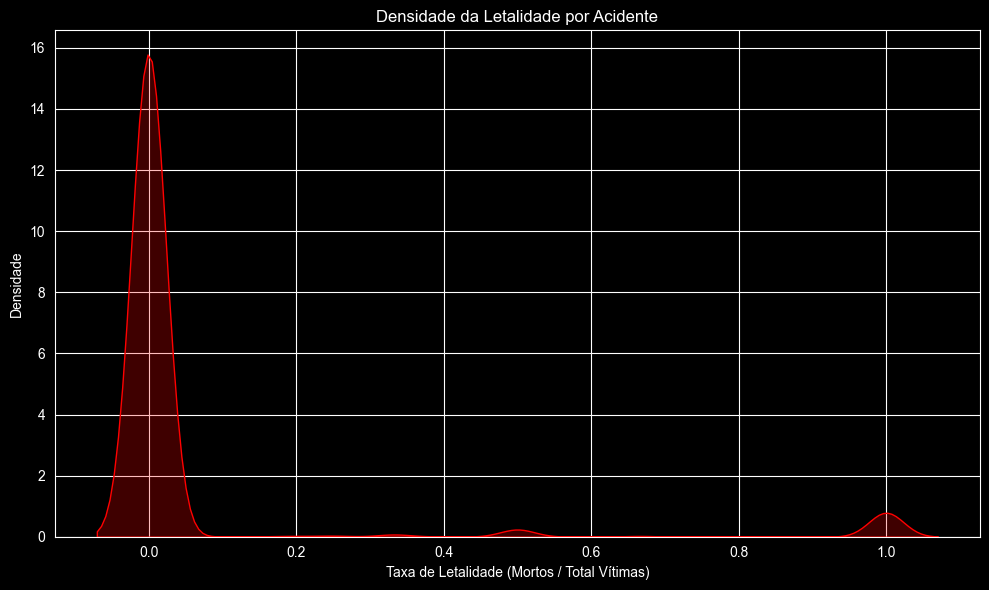

In [56]:
plt.figure(figsize=(10,6))
sns.kdeplot(prf_acidentes_2025['letalidade_acidente'], shade=True, color='red')
plt.title('Densidade da Letalidade por Acidente')
plt.xlabel('Taxa de Letalidade (Mortos / Total Vítimas)')
plt.ylabel('Densidade')
plt.tight_layout()

- O eixo x representa a taxa de letalidade (proporção de mortos sobre o total de vítimas).

- O eixo y mostra a densidade, ou seja, a frequência relativa dos valores.

- O gráfico tem um pico muito alto próximo de 0,0, indicando que a maioria dos acidentes tem letalidade muito baixa (poucos mortos em relação ao total de vítimas).

- Há pequenos picos próximos de 0,6 e 1,0, mostrando que existem acidentes menos frequentes, mas com letalidade altíssima — nesses casos, quase todas ou todas as vítimas morrem.

#### Interpretação

- A maior parte dos acidentes não resulta em mortes, mas sim em feridos.

- Uma minoria de acidentes concentra a letalidade extrema, sendo os mais perigosos e críticos para políticas de prevenção.

- Isso reforça que não basta olhar apenas para o número total de acidentes: é preciso considerar também a gravidade, já que poucos eventos podem gerar muitas mortes.

##### Gráfico de Dispersão com Legendas - Mortos vs Veículos Envolvidos 

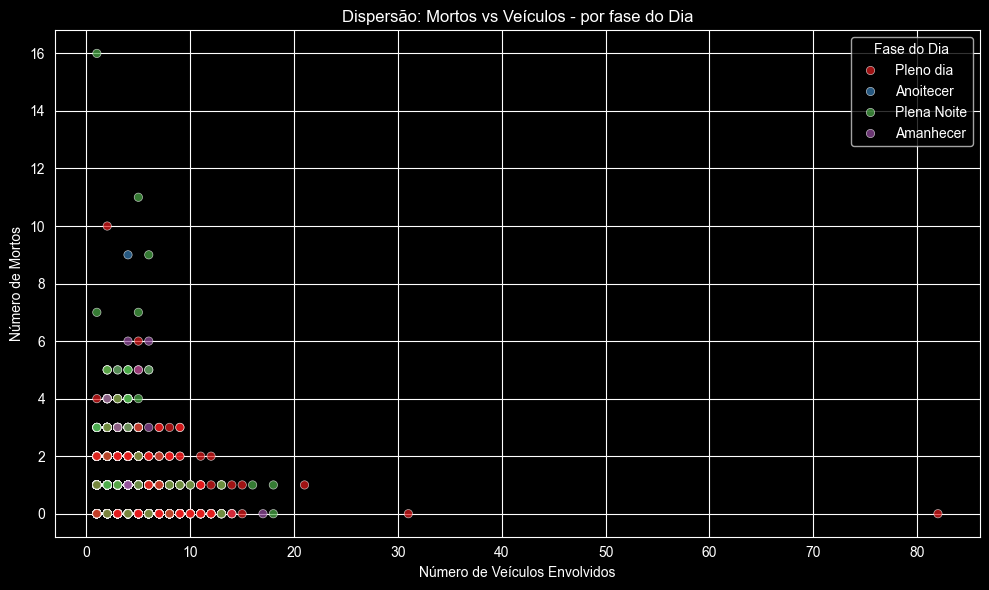

In [57]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='veiculos', y='mortos', hue='fase_dia', data=prf_acidentes_2025, palette='Set1', alpha=0.7)
plt.title('Dispersão: Mortos vs Veículos - por fase do Dia')
plt.xlabel('Número de Veículos Envolvidos')
plt.ylabel('Número de Mortos')
plt.legend(title = 'Fase do Dia')
plt.tight_layout()
plt.show()

#### Causas de Acidentes (ordenado por total de acidentes)

In [58]:
causas_totais = prf_acidentes_2025['causa_acidente'].value_counts().reset_index()
causas_totais.columns = ['causa_acidente', 'total_acidentes']
causas_totais = causas_totais.sort_values('total_acidentes', ascending=False)

In [59]:
# Cálculo de percentual acumulado
causas_totais['percentual'] = causas_totais['total_acidentes'] / causas_totais['total_acidentes'].sum()

In [60]:
causas_totais['percentual_acumulado'] = causas_totais['percentual'].cumsum()

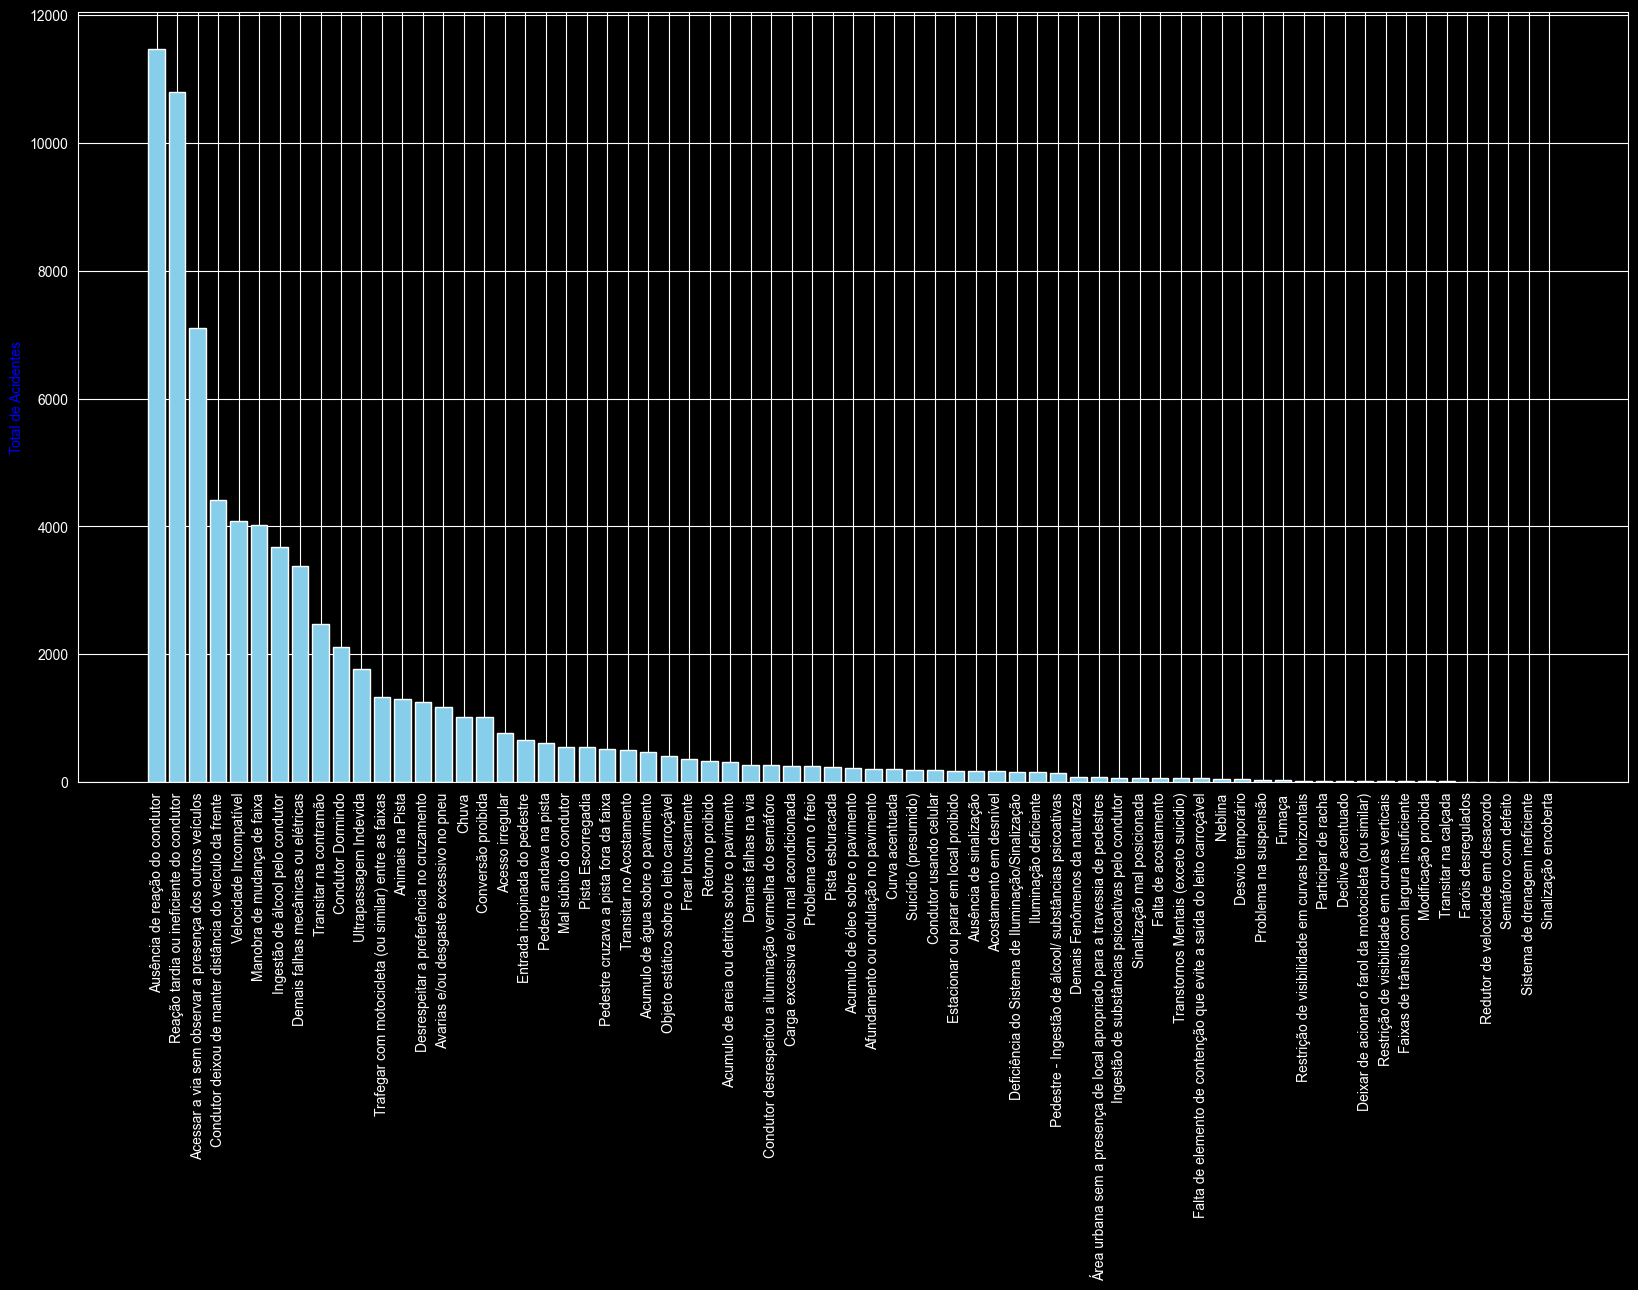

In [70]:
fig, ax1 = plt.subplots(figsize=(20,10))
ax1.bar(causas_totais['causa_acidente'], causas_totais['total_acidentes'], color = 'skyblue')
ax1.set_ylabel('Total de Acidentes', color='blue')
ax1.tick_params(axis='x', rotation=90)

- Ausência de reação do condutor

- Reação tardia ou ineficiente

- Conduzir sob efeito de álcool

- Entre várias outras.

- O eixo y mostra o total de ocorrências, chegando a valores próximos de 12 mil em algumas categorias.

- As primeiras causas listadas (ligadas ao comportamento do condutor) aparecem com os maiores números, indicando que falhas humanas são predominantes.

#### Interpretação

A maioria dos acidentes está relacionada a conduta do motorista — seja por falta de reação, reação tardia ou dirigir alcoolizado.

Fatores externos (como pista, clima ou infraestrutura) aparecem, mas em menor frequência.

Ou seja, o comportamento humano é o principal responsável pelo volume de acidentes, enquanto outros fatores influenciam mais na gravidade/letalidade (como vimos nos gráficos anteriores).

##### Percentual de Acidentes por Fase do Dia

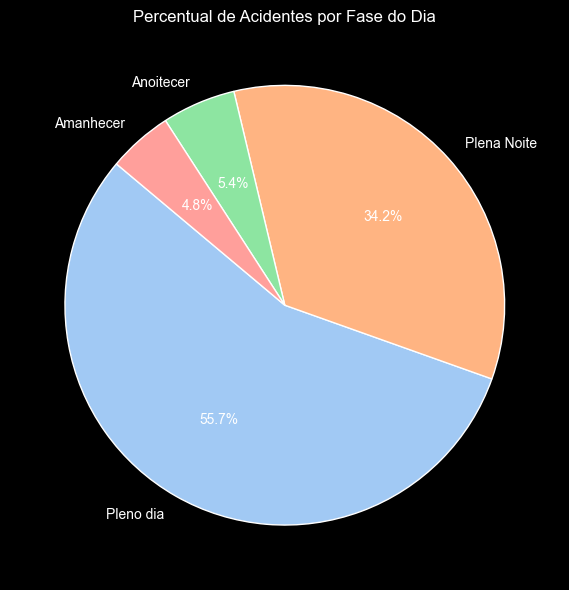

In [84]:
fase_counts = prf_acidentes_2025['fase_dia'].value_counts()
plt.figure(figsize=(10,6))
fase_counts.plot.pie(autopct='%1.1f%%', colors = sns.color_palette('pastel'), startangle=140)
plt.title('Percentual de Acidentes por Fase do Dia')
plt.ylabel('')
plt.tight_layout()
plt.show()

- Pleno dia → concentra a maioria dos acidentes, com 55,7%. Isso reflete o maior fluxo de veículos em horários comerciais e de rotina.

- Plena noite → aparece em segundo lugar, com 34,2%, indicando que mesmo com menor tráfego, fatores como álcool, fadiga e visibilidade reduzida aumentam os riscos.

- Anoitecer → representa 5,4%, período de transição de luz que pode confundir motoristas.

- Amanhecer → com 4,8%, também é uma fase crítica pela mudança brusca de luminosidade.

#### Interpretação

- O dia concentra mais acidentes em volume, mas nem sempre os mais letais.

- A noite concentra acidentes graves, mesmo com menos tráfego.

- Transições de luz (amanhecer e anoitecer), embora menos frequentes, são pontos críticos para a segurança viária.

#### Distribuição do Número de Mortos por Causa do Acidente

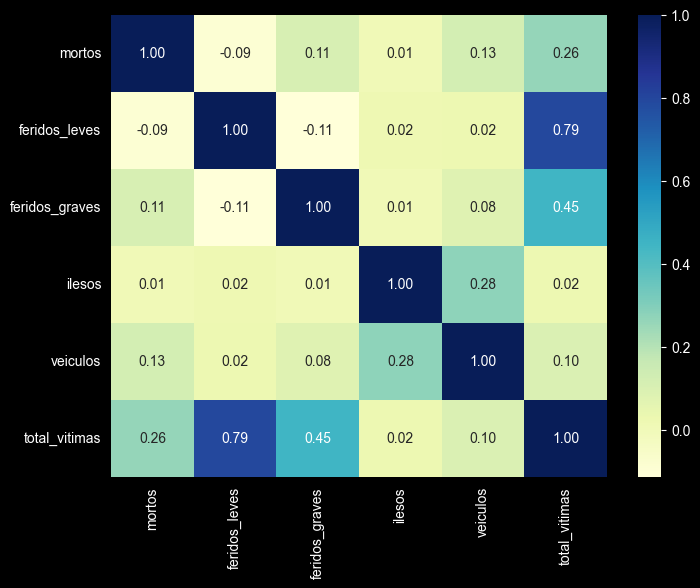

<Figure size 640x480 with 0 Axes>

In [90]:
corr_cols = ['mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos', 'total_vitimas']
corr = prf_acidentes_2025[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.figure('Mapa de Correlação entre Variáveis de Acidentes')
plt.tight_layout()
plt.show()


Mortos

- Correlação baixa com quase todas as variáveis (máximo 0,26 com total de vítimas).

- Isso mostra que o número de mortos não cresce proporcionalmente ao número de vítimas ou veículos envolvidos.

Feridos leves

- Forte correlação com total de vítimas (0,79).

- Ou seja, quando há muitos feridos leves, o total de vítimas aumenta bastante.

Feridos graves

- Correlação moderada com total de vítimas (0,45).

- Indica que acidentes com feridos graves contribuem para aumentar o total, mas não tanto quanto os feridos leves.

Ilesos

- Correlação relevante apenas com veículos (0,28). Faz sentido: mais veículos envolvidos → mais pessoas saem ilesas.

Veículos

- Correlação baixa com mortos (0,13) e total de vítimas (0,10). Mostra que envolver mais veículos não significa necessariamente mais mortes.